In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math
import scienceplots

In [5]:
HEADERS = ["scene_name","exp_name","raw","start_time","end_time","duration","it/sec","size"]
HEADERS_RENDER = ["scene_name", "exp_name", "raw", "n_samples", "ref_voxels", "gca_time", "patch_time", "update_gaussian_time", "grown_voxels_gca", "grown_voxels_patch"]
report = pd.read_csv("experiments/results/performance3/report.txt", names=HEADERS)
report_render = pd.read_csv("experiments/results/performance3/report_render.txt", names=HEADERS_RENDER)

In [6]:
report
report_render

,scene_name,exp_name,raw,n_samples,ref_voxels,gca_time,patch_time,update_gaussian_time,grown_voxels_gca,grown_voxels_patch
0,seocho/wall_flowers,template_mult=2_res=1_channels=16,ablation_1.npz,10,4188,0.236603,0.107056,0.010687,44257.9,43014.3
1,campus/delivery,template_mult=2_res=1_channels=16,old.npz,10,6179,0.288615,0.165538,0.008499,66870.9,66389.5
2,campus/vending2,template_mult=2_res=1_channels=16,000000.npz,10,2064,0.134955,0.045693,0.004472,26189.2,24748.6
3,daejeon/pineapple,template_mult=2_res=1_channels=16,000000.npz,10,8613,0.533526,0.402222,0.013225,126146.5,122217.2
4,daejeon/pole,template_mult=2_res=1_channels=16,000002.npz,10,12670,0.600099,0.464367,0.012839,97017.5,116179.0
5,daejeon/onion,template_mult=2_res=1_channels=16,000000.npz,10,16266,0.776969,0.427438,0.010725,127608.3,89905.1
6,daejeon/pond,template_mult=2_res=1_channels=16,000005.npz,10,16531,1.089370,1.991477,0.020555,199400.8,221476.4
7,daejeon/town,template_mult=2_res=1_channels=16,000000.npz,10,7950,0.314075,0.198936,0.008907,66093.3,67538.4
8,daejeon/wood_wall_1,template_mult=2_res=1_channels=16,000002.npz,10,13656,0.462536,0.294526,0.009085,76538.4,71486.8
9,daejeon/wood_wall_3,template_mult=2_res=1_channels=16,000000.npz,10,13564,0.537345,0.283596,0.009571,94657.0,68622.8


In [7]:
report["duration_min"] = report["duration"]/60

In [8]:
report_render["gca_time_ms"] = report_render["gca_time"] * 1000
report_render["patch_time_ms"] = report_render["patch_time"] * 1000

In [9]:
import matplotlib.font_manager
matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

['/usr/share/fonts/truetype/tlwg/TlwgTypo-Bold.ttf',
 '/usr/share/fonts/truetype/tlwg/Waree-BoldOblique.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuMathTeXGyre.ttf',
 '/usr/share/fonts/opentype/urw-base35/NimbusSansNarrow-Bold.otf',
 '/usr/share/fonts/truetype/tlwg/Umpush-Oblique.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Bold.ttf',
 '/usr/share/fonts/truetype/samyak-fonts/Samyak-Tamil.ttf',
 '/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf',
 '/usr/share/fonts/opentype/urw-base35/NimbusMonoPS-Italic.otf',
 '/usr/share/fonts/truetype/tlwg/TlwgMono-Bold.ttf',
 '/usr/share/fonts/truetype/tlwg/Sawasdee.ttf',
 '/usr/share/fonts/truetype/fonts-yrsa-rasa/Yrsa-MediumItalic.ttf',
 '/usr/share/fonts/truetype/teluguvijayam/TenaliRamakrishna-Regular.ttf',
 '/usr/share/fonts/truetype/tlwg/TlwgTypist-BoldOblique.ttf',
 '/usr/share/fonts/truetype/noto/NotoColorEmoji.ttf',
 '/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf',
 '/usr/share/fonts/o

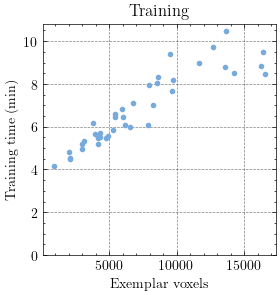

In [25]:
# Style
plt.style.use(['science', "grid",  "scatter",  "light"])
plt.rcParams["font.family"] = "Linux Libertine"

plt.figure(figsize=(3, 3))
plt.scatter(report_render["ref_voxels"], report["duration_min"])
# plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: (f"${v/math.pow(10, int(math.log(v,10))):.1f} \\times 10^{int(math.log(v,10))}$" if v != 0 else "0") ))
plt.xlabel("Exemplar voxels")
plt.ylim(bottom=0)
plt.ylabel("Training time (min)")
plt.title("Training")
plt.savefig("training.pdf")
plt.show()

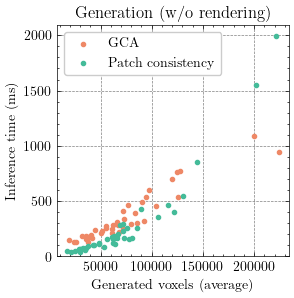

In [30]:
plt.figure(figsize=(3,3))
plt.scatter(report_render["grown_voxels_gca"], report_render["gca_time_ms"], label="GCA", color="C1")
plt.scatter(report_render["grown_voxels_patch"], report_render["patch_time_ms"], label="Patch consistency", color="C5")
plt.xlabel("Generated voxels (average)")
plt.ylabel("Inference time (ms)")
plt.ylim(bottom=0)
plt.title("Generation (w/o rendering)")
# plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: (f"${v/math.pow(10, int(math.log(v,10))):.1f} \\times 10^{int(math.log(v,10))}$" if v != 0 else "0") ))
plt.legend()
plt.savefig("generation.pdf")
plt.show()

/tmp/ipykernel_177008/3705504444.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


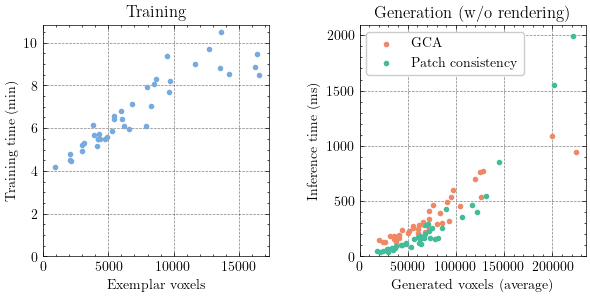

In [37]:
# Style
plt.style.use(['science', "grid",  "scatter",  "light"])
plt.rcParams["font.family"] = "Linux Libertine"

fig, axes = plt.subplots(1, 2, figsize=(7, 3), gridspec_kw=dict(hspace=2, wspace=0.4))

# --------------------
# TRAINING
# --------------------
axes[0].scatter(report_render["ref_voxels"], report["duration_min"])

axes[0].set_xlabel("Exemplar voxels")
axes[0].set_ylim(bottom=0)
axes[0].set_xlim(left=0)
axes[0].set_ylabel("Training time (min)")
axes[0].title.set_text("Training")
axes[0].ticklabel_format(style="sci", axis="x")

axes[1].scatter(report_render["grown_voxels_gca"], report_render["gca_time_ms"], label="GCA", color="C1")
axes[1].scatter(report_render["grown_voxels_patch"], report_render["patch_time_ms"], label="Patch consistency", color="C5")
axes[1].set_xlabel("Generated voxels (average)")
axes[1].set_ylabel("Inference time (ms)")
axes[1].set_ylim(bottom=0)
axes[1].set_xlim(left=0)
axes[1].title.set_text("Generation (w/o rendering)")
# axes[1].ticklabel_format(style="sci", axis="x", scilimits=(0,0), useMathText=True)

plt.legend()
plt.tight_layout()
plt.subplots_adjust(hspace=1.0)

plt.savefig("gen_and_training.pdf")
